# Модель классификации пользовательской оценки Steam

В этом ноутбуке строится бинарная модель: `positive` против `not_positive`. Цель - оценить, можно ли по metadata игры заранее понять, будет ли пользовательская оценка положительной. Для задачи издателя используется порог `P(positive) >= 0.65`, чтобы модель реже называла игру положительной ошибочно.

## Импорты, пути и параметры модели

Здесь задаются признаки, таргет, параметры train/test split и порог положительного класса. В признаки не добавляются `total_positive`, `total_negative` и `review_score_desc`, потому что они напрямую описывают целевую оценку и создавали бы утечку таргета.

In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))


import json
from collections import Counter
from pathlib import Path

from IPython.display import Image, display
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from project_paths import (
    STEAM_GAMES_DATASET_CSV_PATH,
    USER_SCORE_CLASSIFICATION_CONFUSION_PLOT_PATH,
    USER_SCORE_CLASSIFICATION_METRICS_PLOT_PATH,
    USER_SCORE_FEATURE_CORRELATION_PLOT_PATH,
    USER_SCORE_LOGISTIC_VIF_PLOT_PATH,
    USER_SCORE_MODEL_FEATURES_PLOT_PATH,
    USER_SCORE_MODEL_IMPORTANCE_PLOT_PATH,
    USER_SCORE_ROC_PR_PLOT_PATH,
    USER_SCORE_THRESHOLD_METRICS_PLOT_PATH,
)

matplotlib.use("Agg")

DATASET_PATH = STEAM_GAMES_DATASET_CSV_PATH
METRICS_PLOT_PATH = USER_SCORE_CLASSIFICATION_METRICS_PLOT_PATH
CONFUSION_PLOT_PATH = USER_SCORE_CLASSIFICATION_CONFUSION_PLOT_PATH
CORRELATION_PLOT_PATH = USER_SCORE_FEATURE_CORRELATION_PLOT_PATH
LOGISTIC_VIF_PLOT_PATH = USER_SCORE_LOGISTIC_VIF_PLOT_PATH
MODEL_FEATURES_PLOT_PATH = USER_SCORE_MODEL_FEATURES_PLOT_PATH
MODEL_IMPORTANCE_PLOT_PATH = USER_SCORE_MODEL_IMPORTANCE_PLOT_PATH
ROC_PR_PLOT_PATH = USER_SCORE_ROC_PR_PLOT_PATH
THRESHOLD_METRICS_PLOT_PATH = USER_SCORE_THRESHOLD_METRICS_PLOT_PATH

TOP_N_GENRES = 20
TOP_N_CATEGORIES = 30
POSITIVE_THRESHOLD = 0.65
CURRENT_YEAR = 2026
TEST_SIZE = 0.2
RANDOM_STATE = 42
CLASS_LABELS = ["not_positive", "positive"]
HIGH_CORRELATION_THRESHOLD = 0.8
MULTICOLLINEAR_FEATURES_TO_DROP = [
    "game_age_years",
    "genre_Audio Production",
    "category_Family Sharing",
    "genre_Free To Play",
    "category_Shared/Split Screen",
    "category_Tracked Controller Support",
    "category_Online PvP",
]

FEATURE_GROUP_COLORS = {
    "base": "#4C78A8",
    "date": "#F2CF5B",
    "genre": "#72B55B",
    "category": "#F28E2B",
}

TARGET_MAPPING = {
    "Overwhelmingly Positive": "positive",
    "Very Positive": "positive",
    "Positive": "positive",
    "Mostly Positive": "positive",
    "Mixed": "not_positive",
    "Mostly Negative": "not_positive",
    "Negative": "not_positive",
    "Very Negative": "not_positive",
    "Overwhelmingly Negative": "not_positive",
}

## Загрузка датасета

Берем финальный датасет, собранный из metadata и reviews. Дальше `review_score_desc` будет использоваться только для создания целевого класса, но не как фактор модели.

In [2]:
df_raw = pd.read_csv(DATASET_PATH)
print(f"Загружено строк: {len(df_raw)}")
df_raw.head()

Загружено строк: 38372


,appid,name,is_free,developers,publishers,price_final,price_currency,windows,mac,linux,categories,genres,release_date,review_score_desc,total_positive,total_negative
0,10,Counter-Strike,False,"[""Valve""]","[""Valve""]",999.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2000-11-01,Overwhelmingly Positive,253209.0,6724.0
1,20,Team Fortress Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",1999-04-01,Very Positive,7984.0,1183.0
2,30,Day of Defeat,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""Camera Comfort"", ""Color Alte...","[""Action""]",2003-05-01,Very Positive,6595.0,712.0
3,40,Deathmatch Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2001-06-01,Very Positive,2732.0,554.0
4,50,Half-Life: Opposing Force,False,"[""Gearbox Software""]","[""Valve""]",499.0,USD,True,True,True,"[""Single-player"", ""Multi-player"", ""Custom Volu...","[""Action""]",1999-11-01,Overwhelmingly Positive,26953.0,1314.0


## Парсинг списковых признаков

Жанры и категории сохранены в CSV как JSON-строки. Эти функции превращают их в списки, считают самые частые значения и помогают создать one-hot признаки.

In [3]:
def parse_json_list(value: object) -> list[str]:
    # список из json-строки
    try:
        parsed = json.loads(value)
    except (json.JSONDecodeError, TypeError):
        return []

    if not isinstance(parsed, list):
        return []

    return [str(item) for item in parsed if item]


def get_top_items(df: pd.DataFrame, column: str, limit: int) -> list[str]:
    # частые элементы спискового поля
    counter = Counter()

    for items in df[column].apply(parse_json_list):
        counter.update(items)

    return [item for item, _ in counter.most_common(limit)]

## Бинарные признаки и one-hot кодирование

Платформы и `is_free` приводятся к 0/1. Для жанров и категорий создаются отдельные бинарные колонки: `1`, если значение есть у игры, и `0`, если его нет.

In [4]:
def to_binary(series: pd.Series) -> pd.Series:
    # bool в 0/1
    if series.dtype == bool:
        return series.astype(int)

    return series.astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)


def add_list_features(
    features: pd.DataFrame,
    source_df: pd.DataFrame,
    column: str,
    top_items: list[str],
    prefix: str,
) -> None:
    # one-hot признаки жанров и категорий
    parsed_values = source_df[column].apply(lambda value: set(parse_json_list(value)))

    for item in top_items:
        features[f"{prefix}_{item}"] = parsed_values.apply(lambda values: int(item in values))

## Подготовка числовых факторов

Цена остается в центах. Если игра бесплатная, пропущенная цена заменяется на 0; если игра платная, пропуск заменяется медианной ценой платных игр. Дата релиза превращается в год, месяц и возраст игры.

In [5]:
def prepare_features(
    df: pd.DataFrame,
    top_genres: list[str],
    top_categories: list[str],
    current_year: int,
) -> pd.DataFrame:
    # базовые числовые и бинарные признаки
    features = pd.DataFrame(index=df.index)
    features["is_free"] = to_binary(df["is_free"])
    features["windows"] = to_binary(df["windows"])
    features["linux"] = to_binary(df["linux"])
    features["mac"] = to_binary(df["mac"])

    # цена: free игры получают 0, платные пропуски получают медиану
    price = pd.to_numeric(df["price_final"], errors="coerce")
    free_mask = features["is_free"] == 1
    paid_price_median = price[(~free_mask) & price.notna()].median()

    if pd.isna(paid_price_median):
        paid_price_median = 0

    price = price.mask(free_mask & price.isna(), 0)
    features["price_final"] = price.fillna(paid_price_median)

    # дата выхода превращается в год, месяц и возраст игры
    release_date = pd.to_datetime(df["release_date"], errors="coerce")
    features["release_year"] = release_date.dt.year
    features["release_month"] = release_date.dt.month
    features["game_age_years"] = current_year - features["release_year"]

    for column in ["release_year", "release_month", "game_age_years"]:
        median_value = features[column].median()

        if pd.isna(median_value):
            median_value = 0

        features[column] = features[column].fillna(median_value)

    # списковые признаки кодируются по самым частым значениям
    add_list_features(features, df, "genres", top_genres, "genre")
    add_list_features(features, df, "categories", top_categories, "category")

    return features

## Создание таргета и матрицы признаков

Steam-оценки группируются в два класса: `positive` и `not_positive`. Строки с `No user reviews`, числовыми описаниями вида `1 user reviews` и другими нерелевантными значениями исключаются из обучения.

In [6]:
def prepare_model_data(
    df: pd.DataFrame,
    target_mapping: dict[str, str],
    top_n_genres: int,
    top_n_categories: int,
    current_year: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, int]:
    # целевая переменная positive/not_positive
    df = df.copy()
    df["review_class"] = df["review_score_desc"].map(target_mapping)

    excluded_rows = int(df["review_class"].isna().sum())
    df = df.dropna(subset=["review_class"]).copy()

    # топы считаются после удаления строк без таргета
    top_genres = get_top_items(df, "genres", top_n_genres)
    top_categories = get_top_items(df, "categories", top_n_categories)

    X = prepare_features(
        df=df,
        top_genres=top_genres,
        top_categories=top_categories,
        current_year=current_year,
    )
    y = df["review_class"]

    return df, X, y, excluded_rows

## Подготовка данных для модели

На этом шаге создаются `X` и `y`: матрица факторов и целевой класс. Также выводится распределение классов, чтобы сразу увидеть дисбаланс между `positive` и `not_positive`.

In [7]:
df, X, y, excluded_rows = prepare_model_data(
    df=df_raw,
    target_mapping=TARGET_MAPPING,
    top_n_genres=TOP_N_GENRES,
    top_n_categories=TOP_N_CATEGORIES,
    current_year=CURRENT_YEAR,
)

print(f"Строк после создания таргета: {len(df)}")
print(f"Исключено строк без подходящего таргета: {excluded_rows}")
print(f"Размер матрицы признаков: {X.shape}")

y.value_counts()

Строк после создания таргета: 14823
Исключено строк без подходящего таргета: 23549
Размер матрицы признаков: (14823, 58)


review_class
positive        9991
not_positive    4832
Name: count, dtype: int64

После маппинга Steam-оценок осталось 14823 строки: 9991 `positive` и 4832 `not_positive`. Классы несбалансированы, поэтому простая accuracy может быть обманчивой: модель может выглядеть неплохо просто потому, что положительных игр больше. Поэтому дальше смотрим precision, recall, F1 и матрицу ошибок.

## Диагностика корреляций и VIF

Перед удалением факторов проверяем мультиколлинеарность. Корреляции показывают пары признаков, которые двигаются вместе, а VIF показывает, насколько хорошо один признак объясняется всеми остальными признаками.

In [23]:
def get_high_correlation_pairs(
    X: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    # пары признаков с сильной корреляцией
    correlation = X.corr(numeric_only=True)
    upper_mask = np.triu(np.ones(correlation.shape), k=1).astype(bool)
    upper = correlation.where(upper_mask)
    rows = []

    for left_feature, row in upper.iterrows():
        for right_feature, value in row.dropna().items():
            if abs(value) >= threshold:
                rows.append(
                    {
                        "feature_1": left_feature,
                        "feature_2": right_feature,
                        "correlation": value,
                        "abs_correlation": abs(value),
                    }
                )

    if not rows:
        return pd.DataFrame(
            columns=["feature_1", "feature_2", "correlation", "abs_correlation"]
        )

    return pd.DataFrame(rows).sort_values("abs_correlation", ascending=False)


def compute_vif_table(X: pd.DataFrame) -> pd.DataFrame:
    # vif важен прежде всего для logistic regression
    features = list(X.columns)
    rows = []

    for feature in features:
        y = X[feature]

        if y.nunique(dropna=False) <= 1:
            rows.append({"feature": feature, "vif": np.nan})
            continue

        other_features = [name for name in features if name != feature]
        model = LinearRegression()
        model.fit(X[other_features], y)
        r_squared = model.score(X[other_features], y)

        if r_squared >= 0.999999:
            vif = np.inf
        else:
            vif = 1 / (1 - r_squared)

        rows.append({"feature": feature, "vif": vif})

    vif_df = pd.DataFrame(rows)
    vif_df["vif_for_sort"] = vif_df["vif"].replace(np.inf, np.nan)
    vif_df["vif_for_sort"] = vif_df["vif_for_sort"].fillna(vif_df["vif_for_sort"].max() + 1)

    return vif_df.sort_values("vif_for_sort", ascending=False).drop(columns=["vif_for_sort"])

## Корреляционная матрица факторов


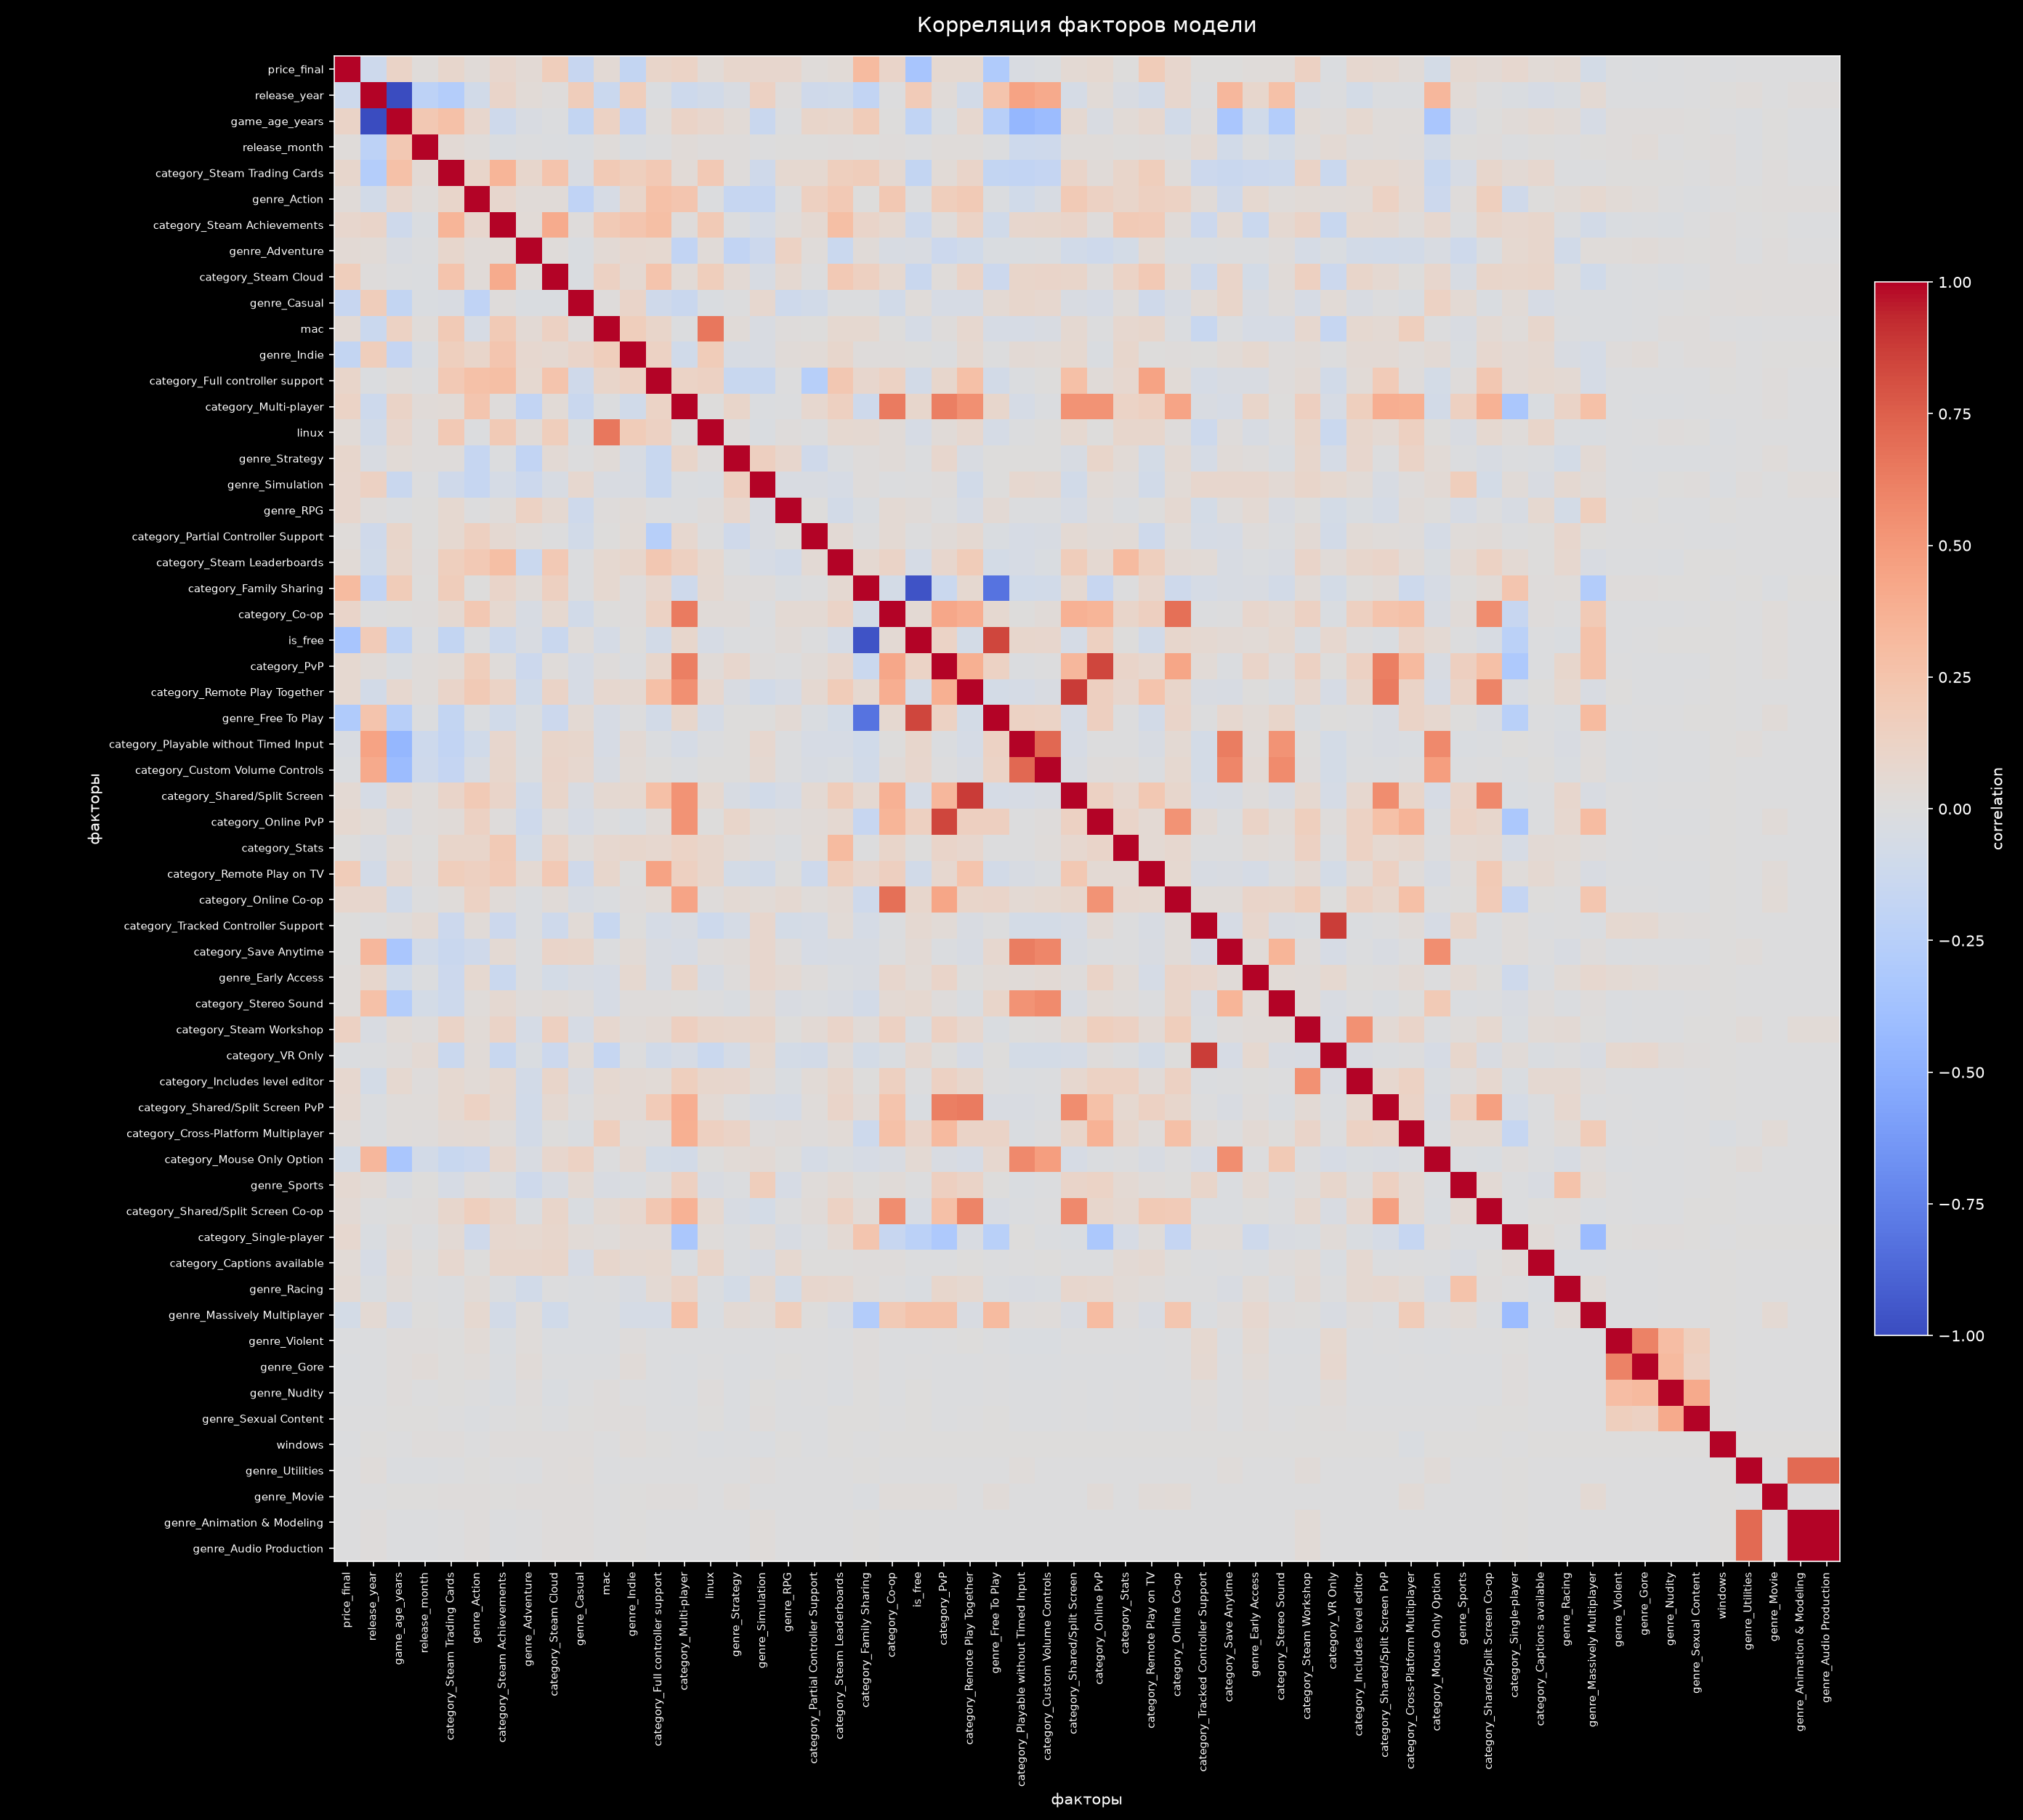

,feature_1,feature_2,correlation,abs_correlation
2,release_year,game_age_years,-1.000000,1.000000
4,genre_Animation & Modeling,genre_Audio Production,1.000000,1.000000
1,is_free,category_Family Sharing,-0.968259,0.968259
6,category_Remote Play Together,category_Shared/Split Screen,0.877436,0.877436
7,category_Tracked Controller Support,category_VR Only,0.869268,0.869268
5,category_PvP,category_Online PvP,0.843109,0.843109
0,is_free,genre_Free To Play,0.836414,0.836414
3,genre_Free To Play,category_Family Sharing,-0.812774,0.812774


In [9]:
def plot_feature_correlation_matrix(
    X: pd.DataFrame,
    path: Path,
    max_features: int = 60,
) -> None:
    # heatmap корреляций финальных признаков
    variances = X.var(numeric_only=True).sort_values(ascending=False)
    selected_features = list(variances.head(max_features).index)
    correlation = X[selected_features].corr(numeric_only=True)

    figure_size = max(15, len(selected_features) * 0.32)
    fig, ax = plt.subplots(figsize=(figure_size, figure_size * 0.9))
    image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(
        "Корреляция факторов модели",
        fontsize=14,
        pad=16,
    )
    ax.set_xticks(range(len(selected_features)), selected_features, rotation=90, fontsize=7)
    ax.set_yticks(range(len(selected_features)), selected_features, fontsize=7)
    ax.set_xlabel("факторы")
    ax.set_ylabel("факторы")
    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label="correlation")
    fig.tight_layout()

    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

high_correlations_df = get_high_correlation_pairs(
    X=X,
    threshold=HIGH_CORRELATION_THRESHOLD,
)
plot_feature_correlation_matrix(X, CORRELATION_PLOT_PATH)
display(Image(filename=str(CORRELATION_PLOT_PATH)))

if high_correlations_df.empty:
    print("Сильно коррелирующих пар не найдено")
else:
    display(high_correlations_df.head(20))

Корреляционная матрица показывает, что часть признаков фактически дублирует друг друга. Самый очевидный пример - `release_year` и `game_age_years`: их корреляция равна `-1`, потому что возраст игры напрямую считается из года релиза. Такие пары особенно мешают интерпретации LogisticRegression.

## VIF до удаления факторов

VIF особенно важен для LogisticRegression, потому что сильная линейная зависимость между признаками делает коэффициенты менее устойчивыми и хуже интерпретируемыми.

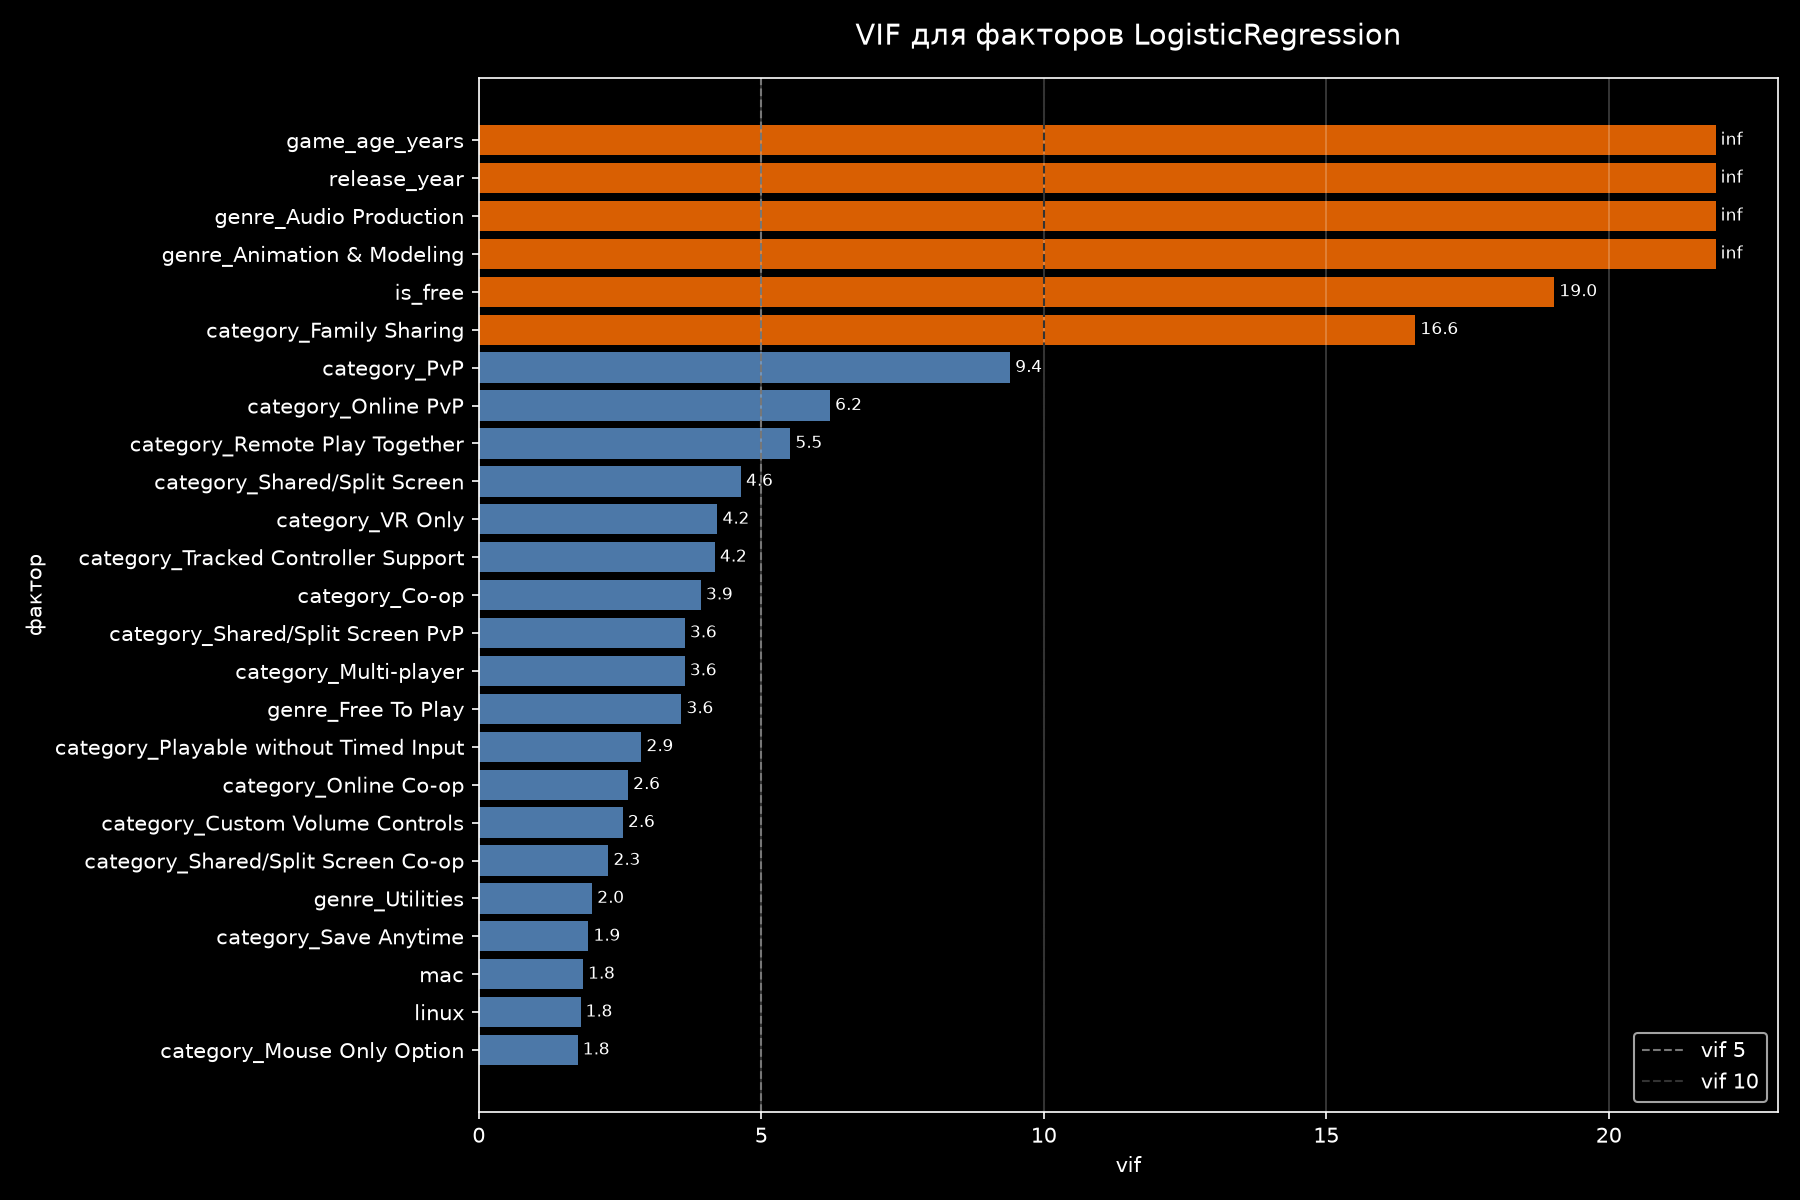

,feature,vif
7,game_age_years,inf
5,release_year,inf
27,genre_Audio Production,inf
26,genre_Animation & Modeling,inf
0,is_free,19.036253
29,category_Family Sharing,16.576969
38,category_PvP,9.406248
43,category_Online PvP,6.218491
39,category_Remote Play Together,5.515237
42,category_Shared/Split Screen,4.641190


In [10]:
def plot_logistic_vif(
    vif_df: pd.DataFrame,
    path: Path,
    top_n: int = 25,
) -> None:
    # топ vif для проверки мультиколлинеарности
    plot_df = vif_df.head(top_n).copy()
    finite_values = plot_df["vif"].replace(np.inf, np.nan)
    cap_value = finite_values.max()

    if pd.isna(cap_value):
        cap_value = 10

    plot_df["vif_for_plot"] = plot_df["vif"].replace(np.inf, cap_value * 1.15)
    plot_df = plot_df.iloc[::-1]

    colors = [
        "#D95F02" if value == np.inf or value >= 10 else "#4C78A8"
        for value in plot_df["vif"]
    ]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(plot_df["feature"], plot_df["vif_for_plot"], color=colors)
    ax.axvline(5, color="#777777", linestyle="--", linewidth=1, label="vif 5")
    ax.axvline(10, color="#333333", linestyle="--", linewidth=1, label="vif 10")
    ax.set_title("VIF для факторов LogisticRegression", fontsize=14, pad=16)
    ax.set_xlabel("vif")
    ax.set_ylabel("фактор")
    ax.grid(axis="x", alpha=0.25)
    ax.legend()

    for bar, value in zip(bars, plot_df["vif"]):
        label = "inf" if value == np.inf else f"{value:.1f}"
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {label}",
            va="center",
            fontsize=8,
        )

    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

vif_df = compute_vif_table(X)
plot_logistic_vif(vif_df, LOGISTIC_VIF_PLOT_PATH)
display(Image(filename=str(LOGISTIC_VIF_PLOT_PATH)))
display(vif_df.head(20))

VIF подтверждает проблему мультиколлинеарности: у `release_year` и `game_age_years` VIF бесконечный, потому что один признак полностью объясняется другим. Также заметна сильная связь `is_free` с признаками вроде `Family Sharing`/`Free To Play`. Для RandomForest это менее критично, но для LogisticRegression такие признаки лучше убрать перед финальным обучением.

## Удаление мультиколлинеарных факторов

После диагностики убираем заранее выбранные признаки с сильным дублированием. Например, `release_year` и `game_age_years` почти полностью несут одну и ту же информацию, поэтому оставляем только один из них.

In [11]:
dropped_multicollinear_features = [
    feature for feature in MULTICOLLINEAR_FEATURES_TO_DROP if feature in X.columns
]
X = X.drop(columns=dropped_multicollinear_features)

print(f"Удаленные мультиколлинеарные факторы: {dropped_multicollinear_features}")
print(f"Итоговый размер матрицы признаков: {X.shape}")

Удалённые мультиколлинеарные факторы: ['game_age_years', 'genre_Audio Production', 'category_Family Sharing', 'genre_Free To Play', 'category_Shared/Split Screen', 'category_Tracked Controller Support', 'category_Online PvP']
Итоговый размер матрицы признаков: (14823, 51)


После удаления мультиколлинеарных факторов в модели остаётся 51 признак. Мы оставляем достаточно информации для обучения, но убираем признаки, которые могли бы делать коэффициенты LogisticRegression нестабильными и сложными для объяснения.

## Разделение на train и test

Данные делятся на 80% для обучения и 20% для проверки. Параметр `stratify=y` сохраняет примерно одинаковую долю классов в train и test.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Строк в train: {len(X_train)}")
print(f"Строк в test: {len(X_test)}")

Строк в train: 11858
Строк в test: 2965


## Создание моделей

Сравниваются две модели. RandomForest строит много деревьев решений и усредняет их ответы. LogisticRegression строит линейную функцию, поэтому для нее добавлена стандартизация признаков через `StandardScaler`.

In [13]:
def create_models(random_state: int) -> dict[str, object]:
    # модели для сравнения
    random_forest = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1,
    )

    logistic_regression = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    class_weight="balanced",
                    random_state=random_state,
                ),
            ),
        ]
    )

    return {
        "RandomForest": random_forest,
        "LogisticRegression": logistic_regression,
    }


def get_estimator(model: object) -> object:
    # модель внутри pipeline
    if isinstance(model, Pipeline):
        return model.named_steps["model"]

    return model

## Вероятность positive и повышенный порог

Модели сначала возвращают вероятность класса `positive`. Затем применяется порог `0.65`: игра считается положительной только если вероятность достаточно высокая.

In [14]:
def get_positive_probabilities(model: object, X_test: pd.DataFrame) -> pd.Series:
    # вероятность класса positive
    estimator = get_estimator(model)
    probabilities = model.predict_proba(X_test)
    positive_index = list(estimator.classes_).index("positive")

    return pd.Series(probabilities[:, positive_index], index=X_test.index)


def apply_positive_threshold(probabilities: pd.Series, positive_threshold: float) -> pd.Series:
    # повышенный порог делает модель осторожнее
    return pd.Series(
        ["positive" if value >= positive_threshold else "not_positive" for value in probabilities],
        index=probabilities.index,
    )

## Обучение моделей

Обе модели обучаются на одном train-наборе и проверяются на одном test-наборе. Это делает сравнение метрик честным.

In [15]:
def train_models(
    models: dict[str, object],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    positive_threshold: float,
) -> dict[str, dict[str, object]]:
    # обучение и предсказания через вероятность positive
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        positive_probability = get_positive_probabilities(model, X_test)
        y_pred = apply_positive_threshold(positive_probability, positive_threshold)
        results[name] = {
            "model": model,
            "y_pred": y_pred,
            "positive_probability": positive_probability,
        }

    return results

models = create_models(random_state=RANDOM_STATE)
results = train_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    positive_threshold=POSITIVE_THRESHOLD,
)
print("Модели обучены")

Модели обучены


## Финальные факторы модели

Перед сравнением качества полезно увидеть, какие признаки попали в модель после one-hot кодирования и удаления мультиколлинеарности.

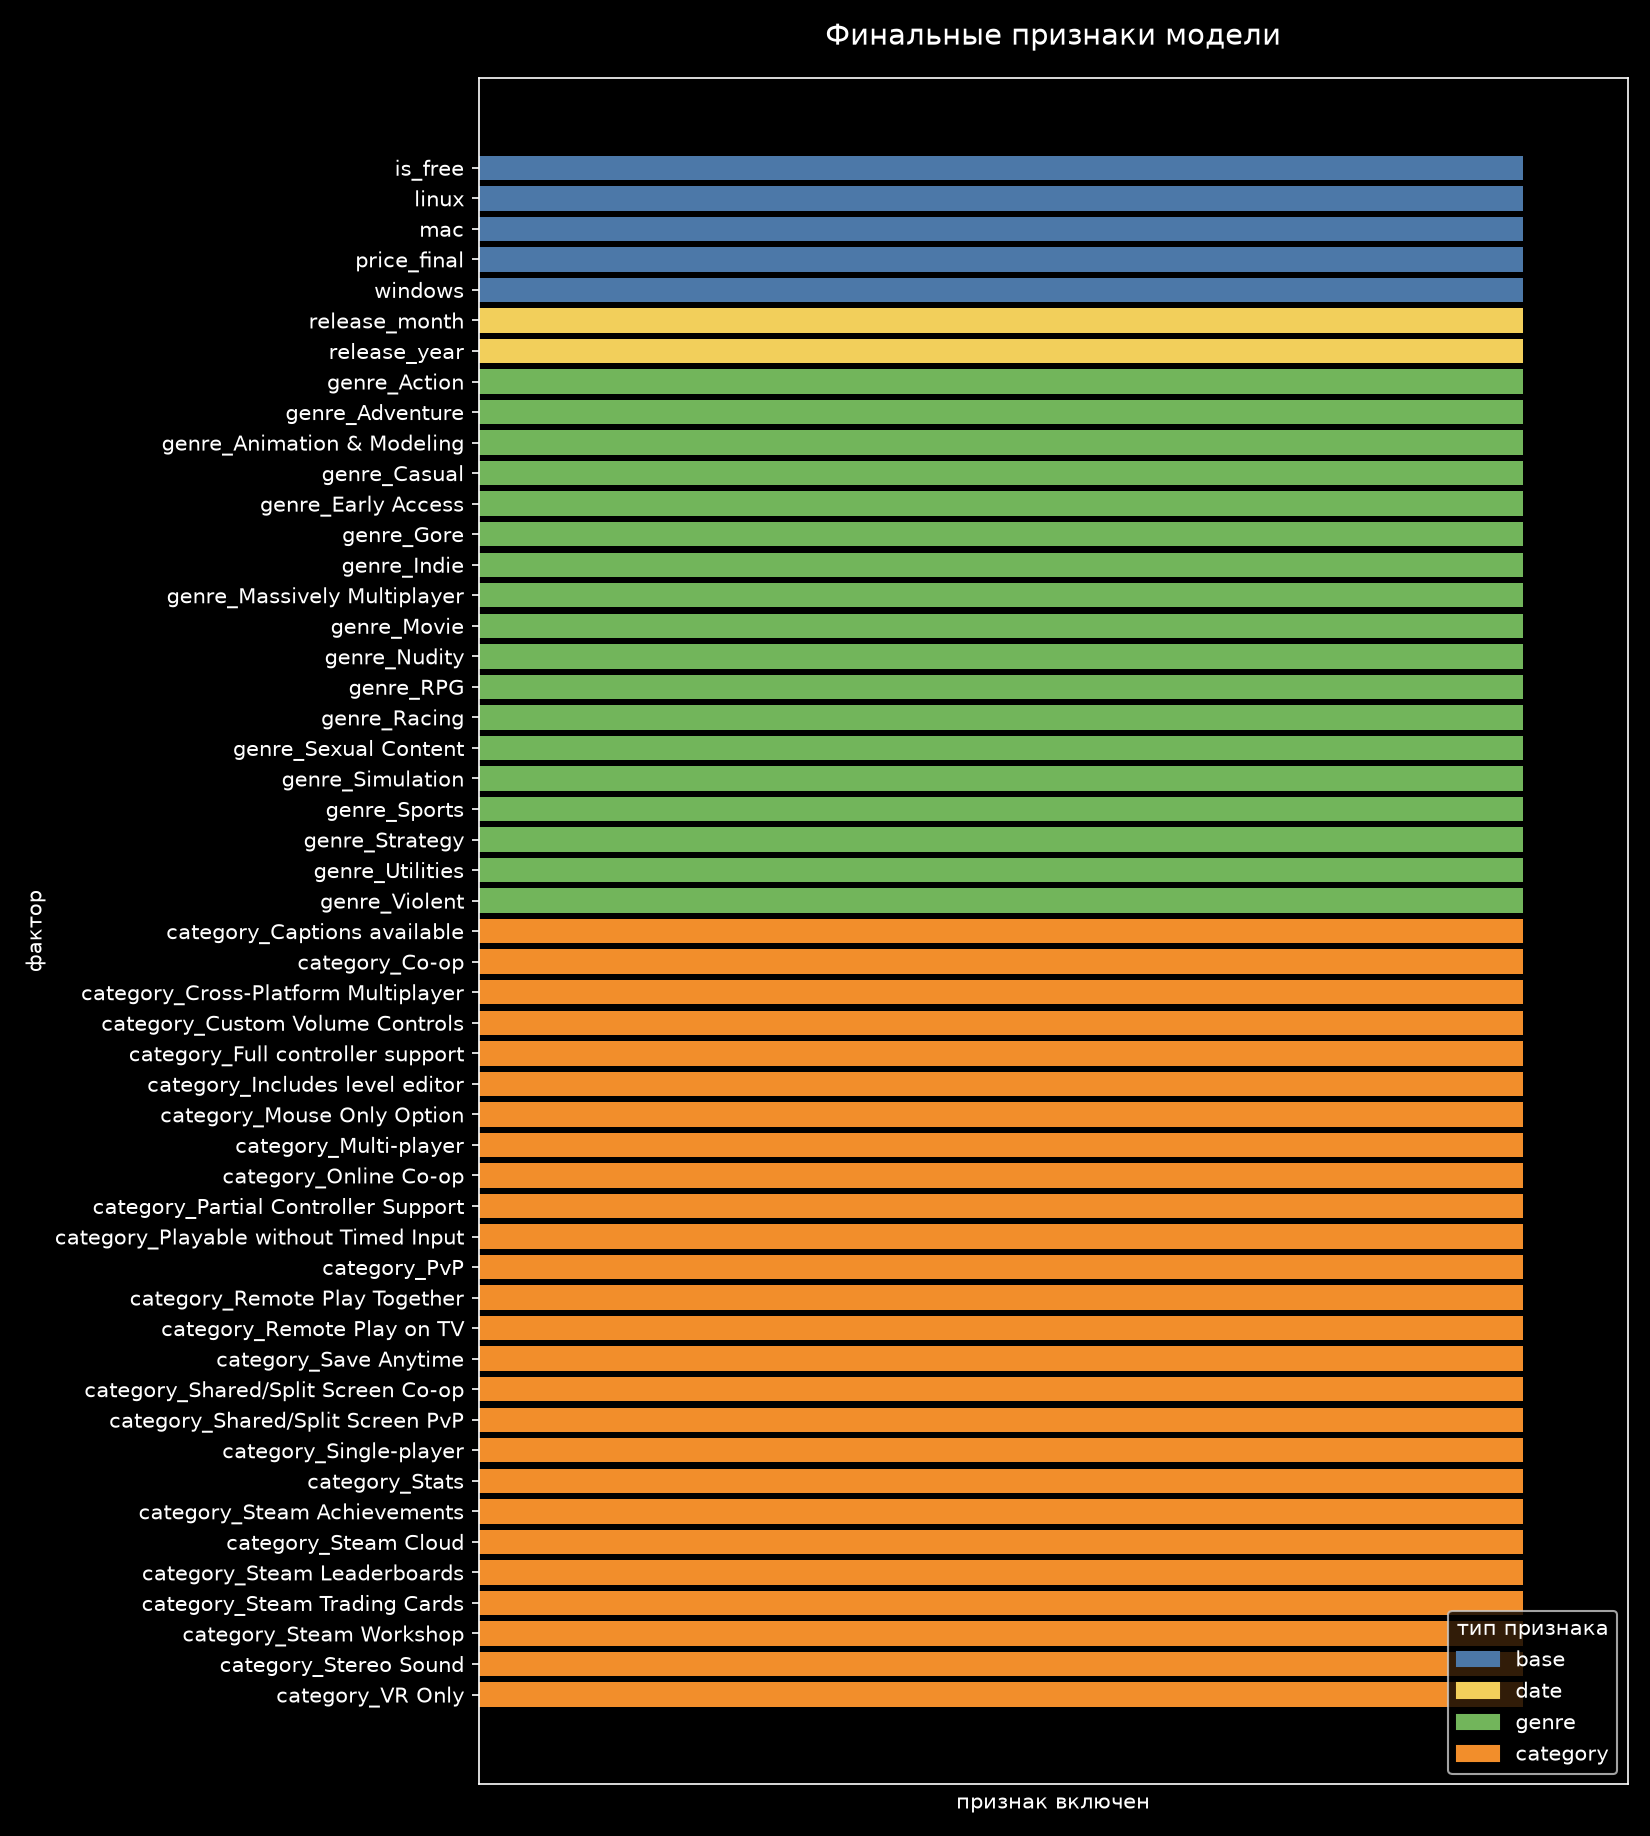

In [16]:
def get_feature_group(feature_name: str) -> str:
    # тип признака по имени колонки
    if feature_name.startswith("genre_"):
        return "genre"

    if feature_name.startswith("category_"):
        return "category"

    if feature_name in ["release_year", "release_month", "game_age_years"]:
        return "date"

    return "base"


def plot_model_features(
    feature_names: list[str],
    path: Path,
) -> None:
    # все признаки, которые ушли в модель
    rows = [
        {
            "feature": feature_name,
            "group": get_feature_group(feature_name),
            "value": 1,
        }
        for feature_name in feature_names
    ]
    plot_df = pd.DataFrame(rows)
    group_order = {"base": 0, "date": 1, "genre": 2, "category": 3}
    plot_df["group_order"] = plot_df["group"].map(group_order)
    plot_df = plot_df.sort_values(["group_order", "feature"], ascending=[True, True])
    plot_df = plot_df.iloc[::-1]

    fig_height = max(9, len(plot_df) * 0.24)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    colors = [FEATURE_GROUP_COLORS[group] for group in plot_df["group"]]
    ax.barh(plot_df["feature"], plot_df["value"], color=colors)
    ax.set_title("Финальные признаки модели", fontsize=14, pad=16)
    ax.set_xlabel("признак включен")
    ax.set_ylabel("фактор")
    ax.set_xlim(0, 1.1)
    ax.set_xticks([])
    ax.grid(False)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=group)
        for group, color in FEATURE_GROUP_COLORS.items()
    ]
    ax.legend(handles=handles, title="тип признака", loc="lower right")
    fig.tight_layout()

    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

plot_model_features(list(X.columns), MODEL_FEATURES_PLOT_PATH)
display(Image(filename=str(MODEL_FEATURES_PLOT_PATH)))

Финальный набор признаков состоит из базовых факторов игры, даты релиза, top-20 жанров и top-30 категорий. Это важно для интерпретации результатов: модель не знает текст отзывов и не использует сами числа положительных/отрицательных отзывов, а пытается предсказывать оценку только по metadata.

## Расчет метрик

Метрики считаются по test-набору. Для задачи издателя особенно важны `positive_precision` и `positive_wrong_rate`: они показывают, насколько рискованно доверять прогнозу `positive`.

In [17]:
def compute_model_metrics(
    y_test: pd.Series,
    y_pred: pd.Series,
    class_labels: list[str],
) -> dict[str, float]:
    # основные метрики и риск ложного positive
    matrix = confusion_matrix(y_test, y_pred, labels=class_labels)
    tn, fp, fn, tp = matrix.ravel()
    predicted_positive = tp + fp
    actual_not_positive = tn + fp

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "positive_precision": precision_score(
            y_test,
            y_pred,
            pos_label="positive",
            zero_division=0,
        ),
        "positive_recall": recall_score(
            y_test,
            y_pred,
            pos_label="positive",
            zero_division=0,
        ),
        "positive_f1": f1_score(
            y_test,
            y_pred,
            pos_label="positive",
            zero_division=0,
        ),
        "not_positive_precision": precision_score(
            y_test,
            y_pred,
            pos_label="not_positive",
            zero_division=0,
        ),
        "not_positive_recall": recall_score(
            y_test,
            y_pred,
            pos_label="not_positive",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_test,
            y_pred,
            labels=class_labels,
            average="macro",
            zero_division=0,
        ),
        "positive_wrong_rate": fp / predicted_positive if predicted_positive else 0,
        "false_positive_rate": fp / actual_not_positive if actual_not_positive else 0,
    }


def get_metrics_table(
    results: dict[str, dict[str, object]],
    y_test: pd.Series,
    class_labels: list[str],
) -> pd.DataFrame:
    # таблица метрик по всем моделям
    rows = []

    for model_name, result in results.items():
        metrics = compute_model_metrics(y_test, result["y_pred"], class_labels)
        metrics["model"] = model_name
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("model")

metrics_df = get_metrics_table(
    results=results,
    y_test=y_test,
    class_labels=CLASS_LABELS,
)
metrics_df

,accuracy,balanced_accuracy,positive_precision,positive_recall,positive_f1,not_positive_precision,not_positive_recall,macro_f1,positive_wrong_rate,false_positive_rate
model,,,,,,,,,,
RandomForest,0.615177,0.657900,0.834504,0.535035,0.652028,0.448337,0.780765,0.610812,0.165496,0.219235
LogisticRegression,0.511636,0.612557,0.872629,0.322322,0.470760,0.392007,0.902792,0.508705,0.127371,0.097208


## График итоговых метрик

График сравнивает RandomForest и LogisticRegression по основным метрикам. Под названиями метрик указаны формулы, чтобы было видно, какие ошибки входят в расчет.

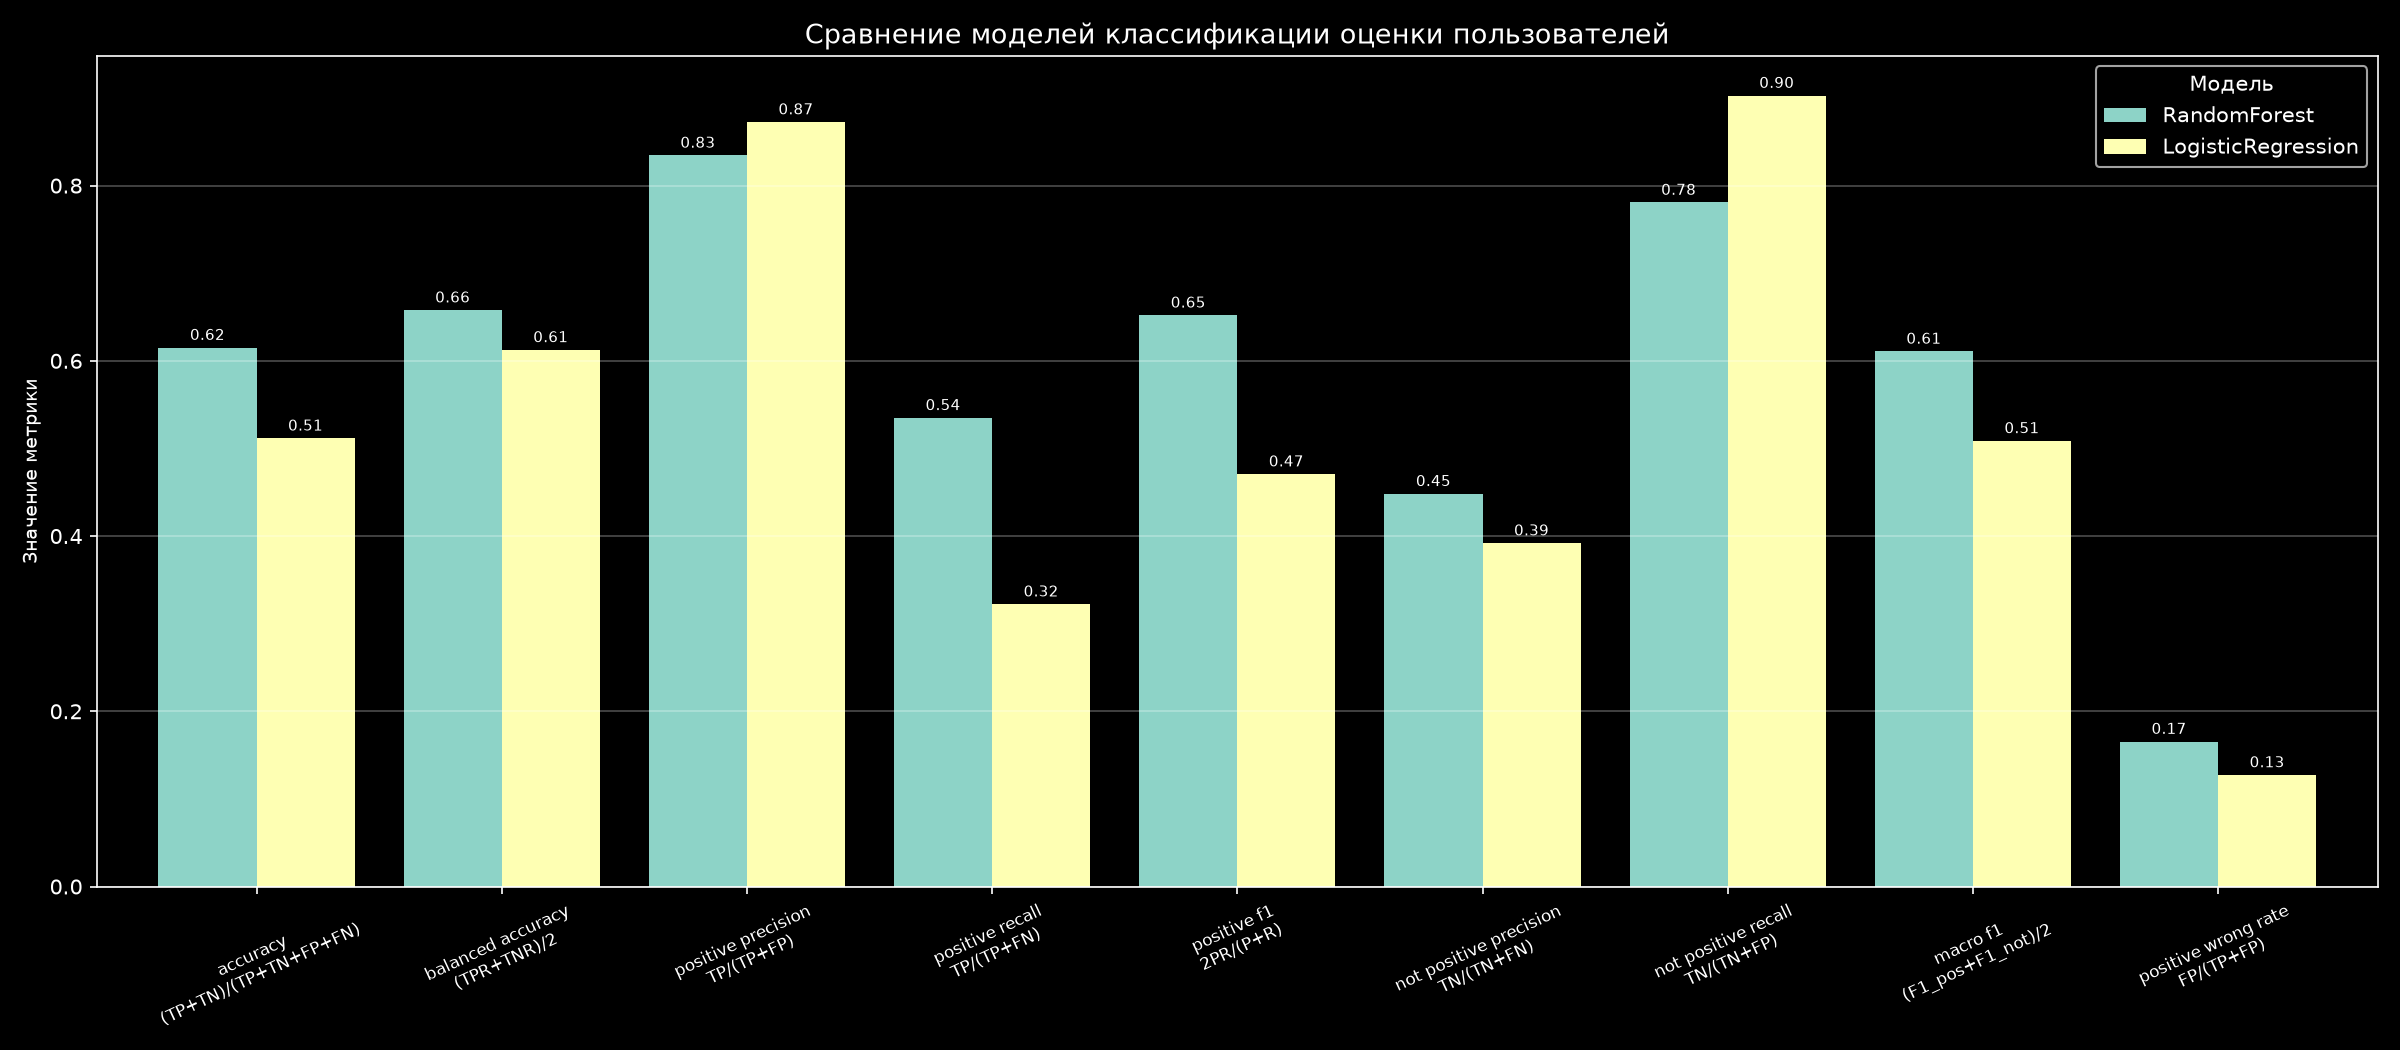

In [18]:
def plot_metrics(metrics_df: pd.DataFrame, path: Path) -> None:
    # график итоговых метрик
    plot_columns = [
        "accuracy",
        "balanced_accuracy",
        "positive_precision",
        "positive_recall",
        "positive_f1",
        "not_positive_precision",
        "not_positive_recall",
        "macro_f1",
        "positive_wrong_rate",
    ]
    plot_df = metrics_df[plot_columns].T
    plot_df.index = [
        "accuracy\n(TP+TN)/(TP+TN+FP+FN)",
        "balanced accuracy\n(TPR+TNR)/2",
        "positive precision\nTP/(TP+FP)",
        "positive recall\nTP/(TP+FN)",
        "positive f1\n2PR/(P+R)",
        "not positive precision\nTN/(TN+FN)",
        "not positive recall\nTN/(TN+FP)",
        "macro f1\n(F1_pos+F1_not)/2",
        "positive wrong rate\nFP/(TP+FP)",
    ]

    fig, ax = plt.subplots(figsize=(16, 7))
    plot_df.plot(kind="bar", ax=ax, rot=25, width=0.8)
    ax.set_title("Сравнение моделей классификации оценки пользователей", fontsize=13)
    ax.set_ylabel("Значение метрики", fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.legend(title="Модель")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

    ax.tick_params(axis="x", labelsize=8)
    plt.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

plot_metrics(metrics_df, METRICS_PLOT_PATH)
display(Image(filename=str(METRICS_PLOT_PATH)))

RandomForest показывает более сбалансированное качество: accuracy около `0.615`, positive recall около `0.535`, positive precision около `0.835`. LogisticRegression осторожнее: positive precision выше, около `0.873`, но recall ниже, около `0.322`. То есть LogisticRegression реже ошибочно говорит `positive`, но пропускает больше реально положительных игр.

## Матрица ошибок

Confusion matrix показывает четыре типа исходов: `TN`, `FP`, `FN`, `TP`. В ячейках есть количество объектов, доля по строке `row` и доля по колонке `col`.

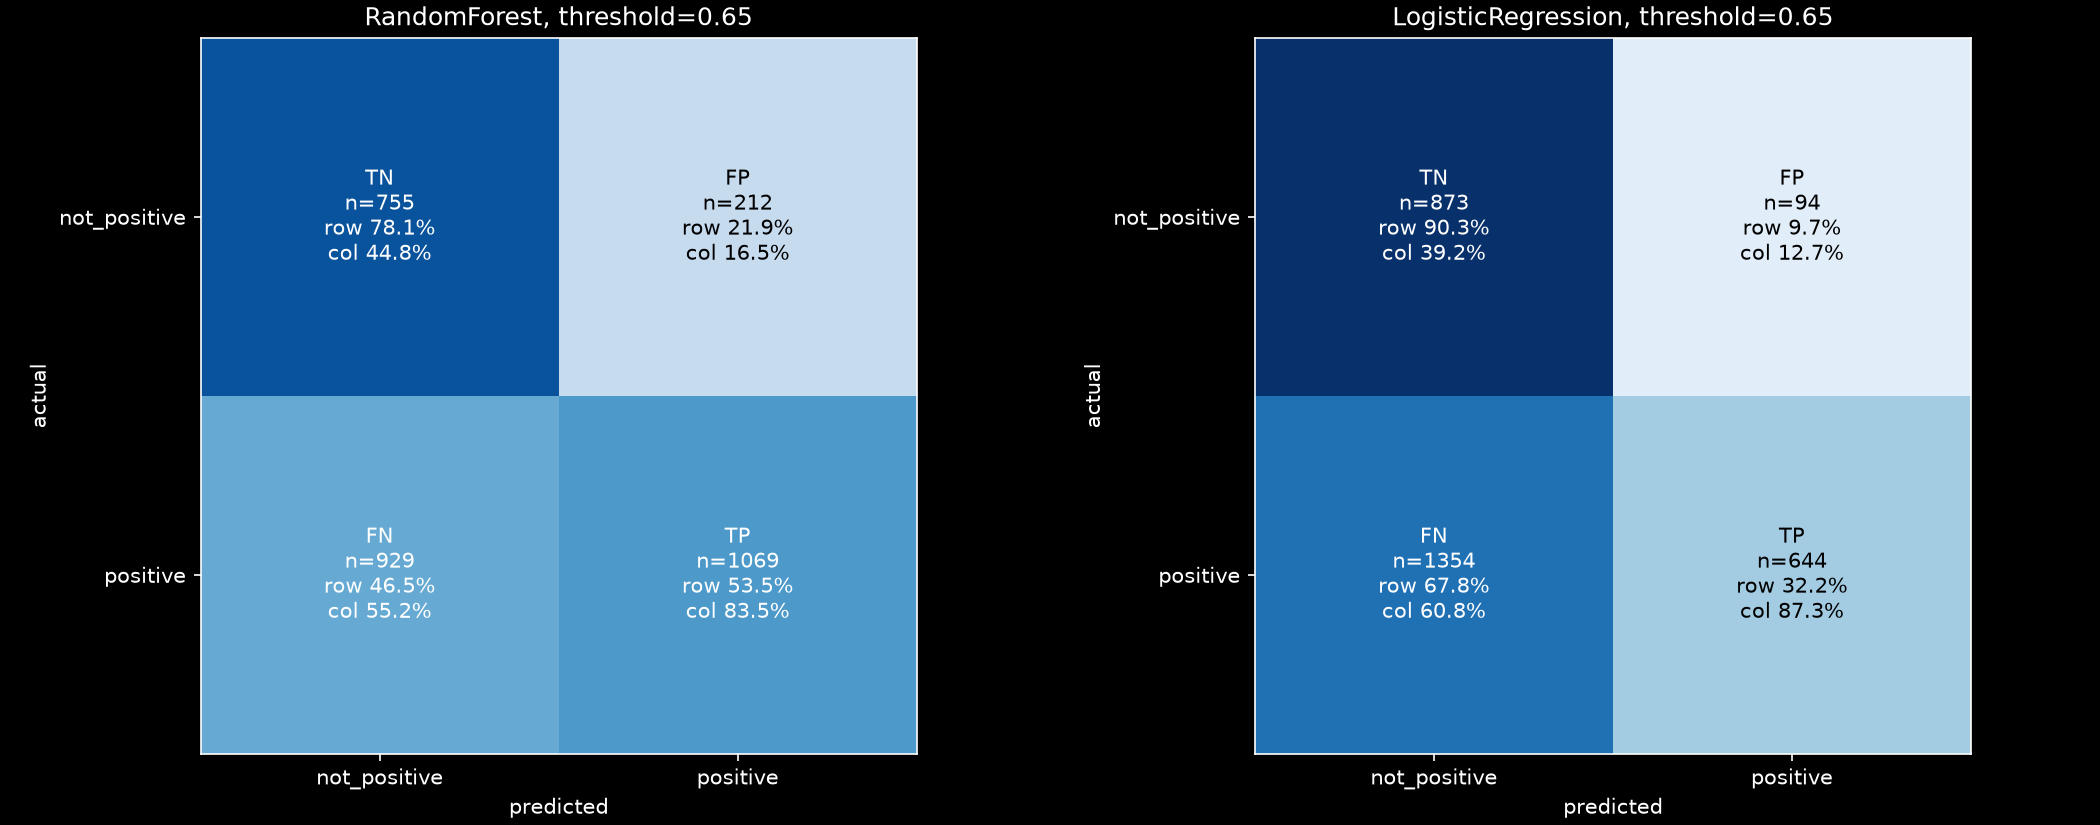

In [19]:
def plot_confusion_matrices(
    results: dict[str, dict[str, object]],
    y_test: pd.Series,
    class_labels: list[str],
    positive_threshold: float,
    path: Path,
) -> None:
    # heatmap ошибок
    matrices = {
        model_name: confusion_matrix(y_test, result["y_pred"], labels=class_labels)
        for model_name, result in results.items()
    }
    row_shares = {
        model_name: pd.DataFrame(matrix).div(matrix.sum(axis=1), axis=0).fillna(0).to_numpy()
        for model_name, matrix in matrices.items()
    }
    column_shares = {
        model_name: pd.DataFrame(matrix).div(matrix.sum(axis=0), axis=1).fillna(0).to_numpy()
        for model_name, matrix in matrices.items()
    }
    max_share = max(share.max() for share in row_shares.values())
    cell_names = [["TN", "FP"], ["FN", "TP"]]

    fig, axes = plt.subplots(
        1,
        len(results),
        figsize=(7 * len(results), 5.5),
        squeeze=False,
        constrained_layout=True,
    )

    for ax, (model_name, matrix) in zip(axes[0], matrices.items()):
        row_share = row_shares[model_name]
        column_share = column_shares[model_name]
        ax.imshow(row_share, cmap="Blues", vmin=0, vmax=max_share)

        ax.set_title(f"{model_name}, threshold={positive_threshold}")
        ax.set_xlabel("predicted")
        ax.set_ylabel("actual")
        ax.set_xticks(range(len(class_labels)), class_labels)
        ax.set_yticks(range(len(class_labels)), class_labels)

        for row_index in range(2):
            for column_index in range(2):
                row_value = row_share[row_index, column_index]
                column_value = column_share[row_index, column_index]
                count = matrix[row_index, column_index]
                color = "white" if row_value > max_share / 2 else "black"
                ax.text(
                    column_index,
                    row_index,
                    f"{cell_names[row_index][column_index]}\nn={count}\nrow {row_value:.1%}\ncol {column_value:.1%}",
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=10,
                )

    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

plot_confusion_matrices(
    results=results,
    y_test=y_test,
    class_labels=CLASS_LABELS,
    positive_threshold=POSITIVE_THRESHOLD,
    path=CONFUSION_PLOT_PATH,
)
display(Image(filename=str(CONFUSION_PLOT_PATH)))

Для издателя самый опасный тип ошибки - `FP`, когда модель сказала `positive`, а игра реально `not_positive`. RandomForest даёт 212 таких ошибок и 1069 верно найденных positive-игр. LogisticRegression даёт меньше FP - 94, но ценой большого числа пропусков positive: 1354 `FN`. Поэтому выбор модели зависит от риска: больше находить потенциально хорошие игры или сильнее избегать ложного оптимизма.

## ROC и Precision-Recall кривые

ROC показывает, как меняется баланс между true positive rate и false positive rate при разных порогах. Precision-Recall  полезна при дисбалансе классов: она показывает, как меняется точность positive-прогноза при попытке найти больше positive-игр.

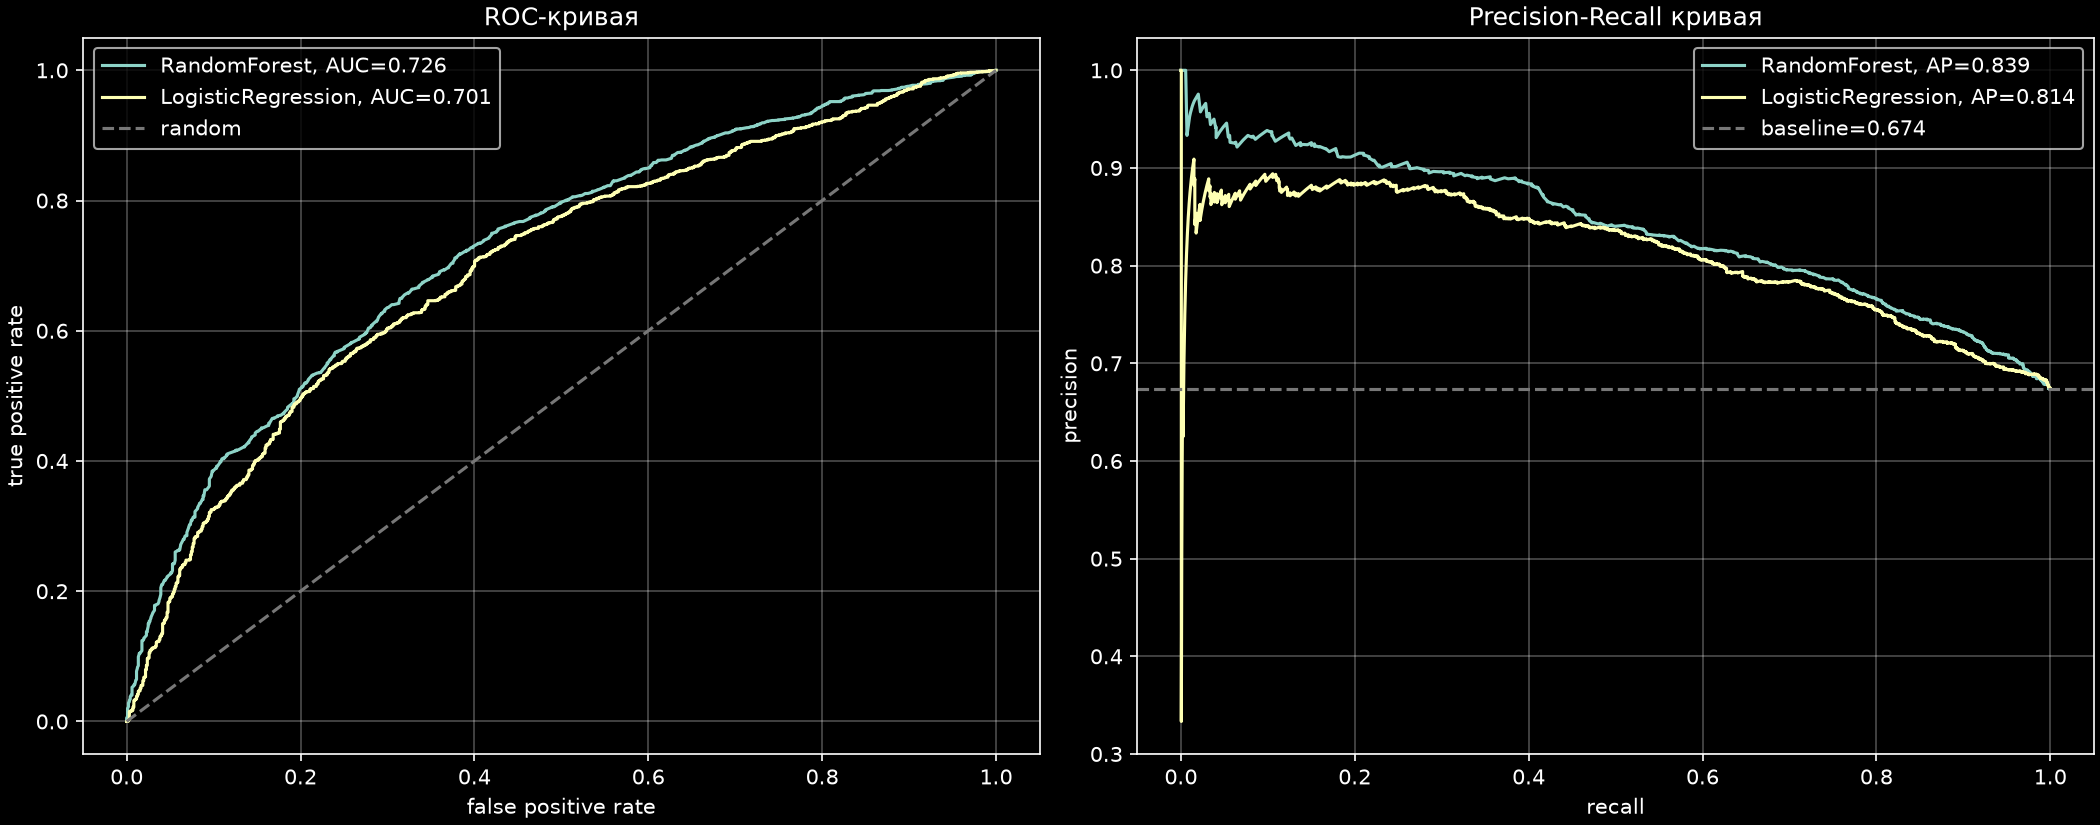

In [20]:
def plot_roc_pr_curves(
    results: dict[str, dict[str, object]],
    y_test: pd.Series,
    path: Path,
) -> None:
    # roc и precision-recall по вероятностям positive
    y_true = (y_test == "positive").astype(int)
    positive_rate = y_true.mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
    roc_ax, pr_ax = axes

    for model_name, result in results.items():
        probabilities = result["positive_probability"]

        fpr, tpr, _ = roc_curve(y_true, probabilities)
        roc_auc = roc_auc_score(y_true, probabilities)
        roc_ax.plot(fpr, tpr, label=f"{model_name}, AUC={roc_auc:.3f}")

        precision, recall, _ = precision_recall_curve(y_true, probabilities)
        average_precision = average_precision_score(y_true, probabilities)
        pr_ax.plot(recall, precision, label=f"{model_name}, AP={average_precision:.3f}")

    roc_ax.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="random")
    roc_ax.set_title("ROC-кривая")
    roc_ax.set_xlabel("false positive rate")
    roc_ax.set_ylabel("true positive rate")
    roc_ax.grid(alpha=0.3)
    roc_ax.legend()

    pr_ax.axhline(
        positive_rate,
        linestyle="--",
        color="#777777",
        label=f"baseline={positive_rate:.3f}",
    )
    pr_ax.set_title("Precision-Recall кривая")
    pr_ax.set_xlabel("recall")
    pr_ax.set_ylabel("precision")
    pr_ax.grid(alpha=0.3)
    pr_ax.legend()

    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

plot_roc_pr_curves(
    results=results,
    y_test=y_test,
    path=ROC_PR_PLOT_PATH,
)
display(Image(filename=str(ROC_PR_PLOT_PATH)))

ROC AUC у RandomForest около `0.726`, у LogisticRegression около `0.701`, то есть обе модели лучше случайного угадывания, но запас качества умеренный. AP на Precision-Recall кривой выше у RandomForest (`0.839` против `0.814`), поэтому он лучше ранжирует игры по вероятности positive, хотя модель всё ещё нельзя считать достаточно сильной для автоматического решения без проверки человеком.

## Метрики при разных порогах

Этот график нужен для выбора порога `positive`. Чем выше порог, тем осторожнее модель называет игру положительной: обычно precision растет, а recall падает.

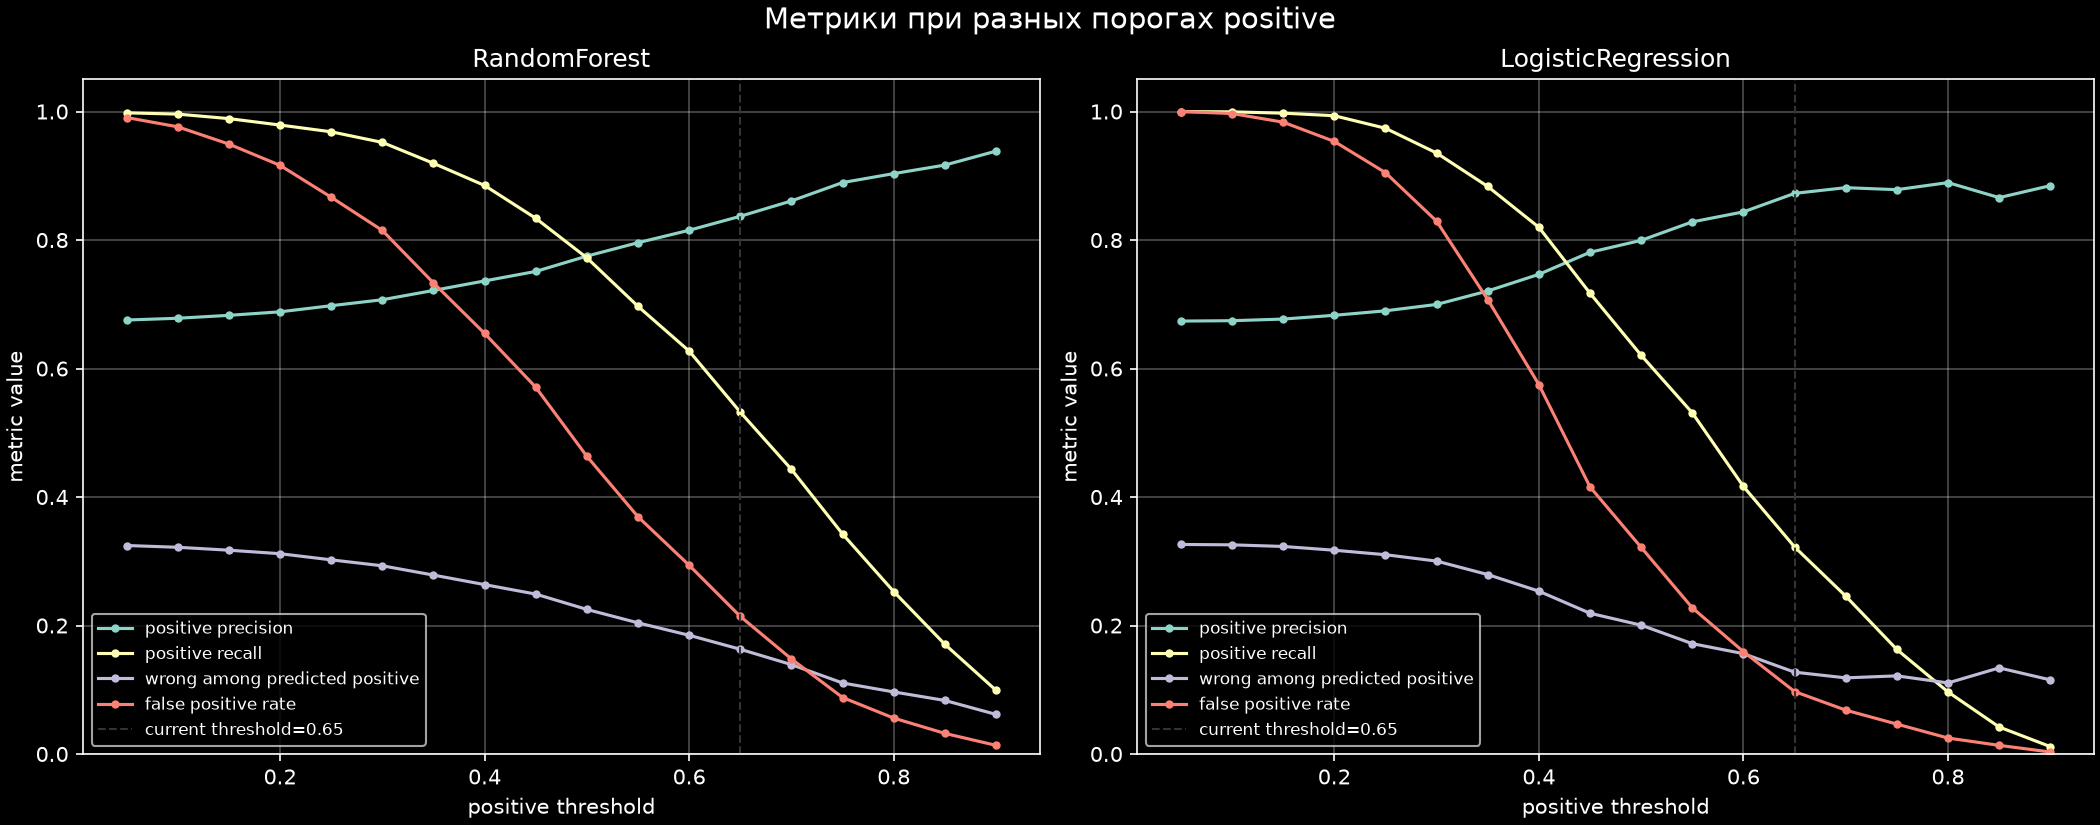

In [21]:
def get_threshold_metrics(
    y_test: pd.Series,
    probabilities: pd.Series,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    # метрики при разных порогах positive
    rows = []

    for threshold in thresholds:
        y_pred = pd.Series(
            np.where(probabilities >= threshold, "positive", "not_positive"),
            index=y_test.index,
        )
        matrix = confusion_matrix(
            y_test,
            y_pred,
            labels=["not_positive", "positive"],
        )
        tn, fp, fn, tp = matrix.ravel()
        predicted_positive = tp + fp
        actual_not_positive = tn + fp

        rows.append(
            {
                "threshold": threshold,
                "positive_precision": precision_score(
                    y_test,
                    y_pred,
                    pos_label="positive",
                    zero_division=0,
                ),
                "positive_recall": recall_score(
                    y_test,
                    y_pred,
                    pos_label="positive",
                    zero_division=0,
                ),
                "positive_f1": f1_score(
                    y_test,
                    y_pred,
                    pos_label="positive",
                    zero_division=0,
                ),
                "positive_wrong_rate": fp / predicted_positive if predicted_positive else 0,
                "false_positive_rate": fp / actual_not_positive if actual_not_positive else 0,
            }
        )

    return pd.DataFrame(rows)


def plot_threshold_metrics(
    results: dict[str, dict[str, object]],
    y_test: pd.Series,
    positive_threshold: float,
    path: Path,
) -> None:
    # как меняются метрики при разных threshold
    thresholds = np.arange(0.05, 0.91, 0.05)
    plot_columns = [
        "positive_precision",
        "positive_recall",
        "positive_wrong_rate",
        "false_positive_rate",
    ]
    plot_labels = {
        "positive_precision": "positive precision",
        "positive_recall": "positive recall",
        "positive_wrong_rate": "wrong among predicted positive",
        "false_positive_rate": "false positive rate",
    }

    fig, axes = plt.subplots(
        1,
        len(results),
        figsize=(7 * len(results), 5.5),
        squeeze=False,
        constrained_layout=True,
    )

    for ax, (model_name, result) in zip(axes[0], results.items()):
        metrics_df = get_threshold_metrics(
            y_test=y_test,
            probabilities=result["positive_probability"],
            thresholds=thresholds,
        )

        for column in plot_columns:
            ax.plot(
                metrics_df["threshold"],
                metrics_df[column],
                marker="o",
                linewidth=1.5,
                markersize=3,
                label=plot_labels[column],
            )

        ax.axvline(
            positive_threshold,
            color="#333333",
            linestyle="--",
            linewidth=1,
            label=f"current threshold={positive_threshold}",
        )
        ax.set_title(model_name)
        ax.set_xlabel("positive threshold")
        ax.set_ylabel("metric value")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle("Метрики при разных порогах positive", fontsize=14)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.close(fig)

plot_threshold_metrics(
    results=results,
    y_test=y_test,
    positive_threshold=POSITIVE_THRESHOLD,
    path=THRESHOLD_METRICS_PLOT_PATH,
)
display(Image(filename=str(THRESHOLD_METRICS_PLOT_PATH)))

График порогов показывает главный компромисс: если повышать threshold для `positive`, модель становится осторожнее и уменьшает долю ложноположительных прогнозов, но одновременно теряет больше реально положительных игр. Текущий порог `0.65` выбран как более осторожный вариант для издателя, которому опаснее переоценить слабую игру.

## Важность факторов

Для RandomForest показана важность признака без направления влияния. Для LogisticRegression показаны коэффициенты: положительные значения двигают прогноз к `positive`, отрицательные - к `not_positive`.

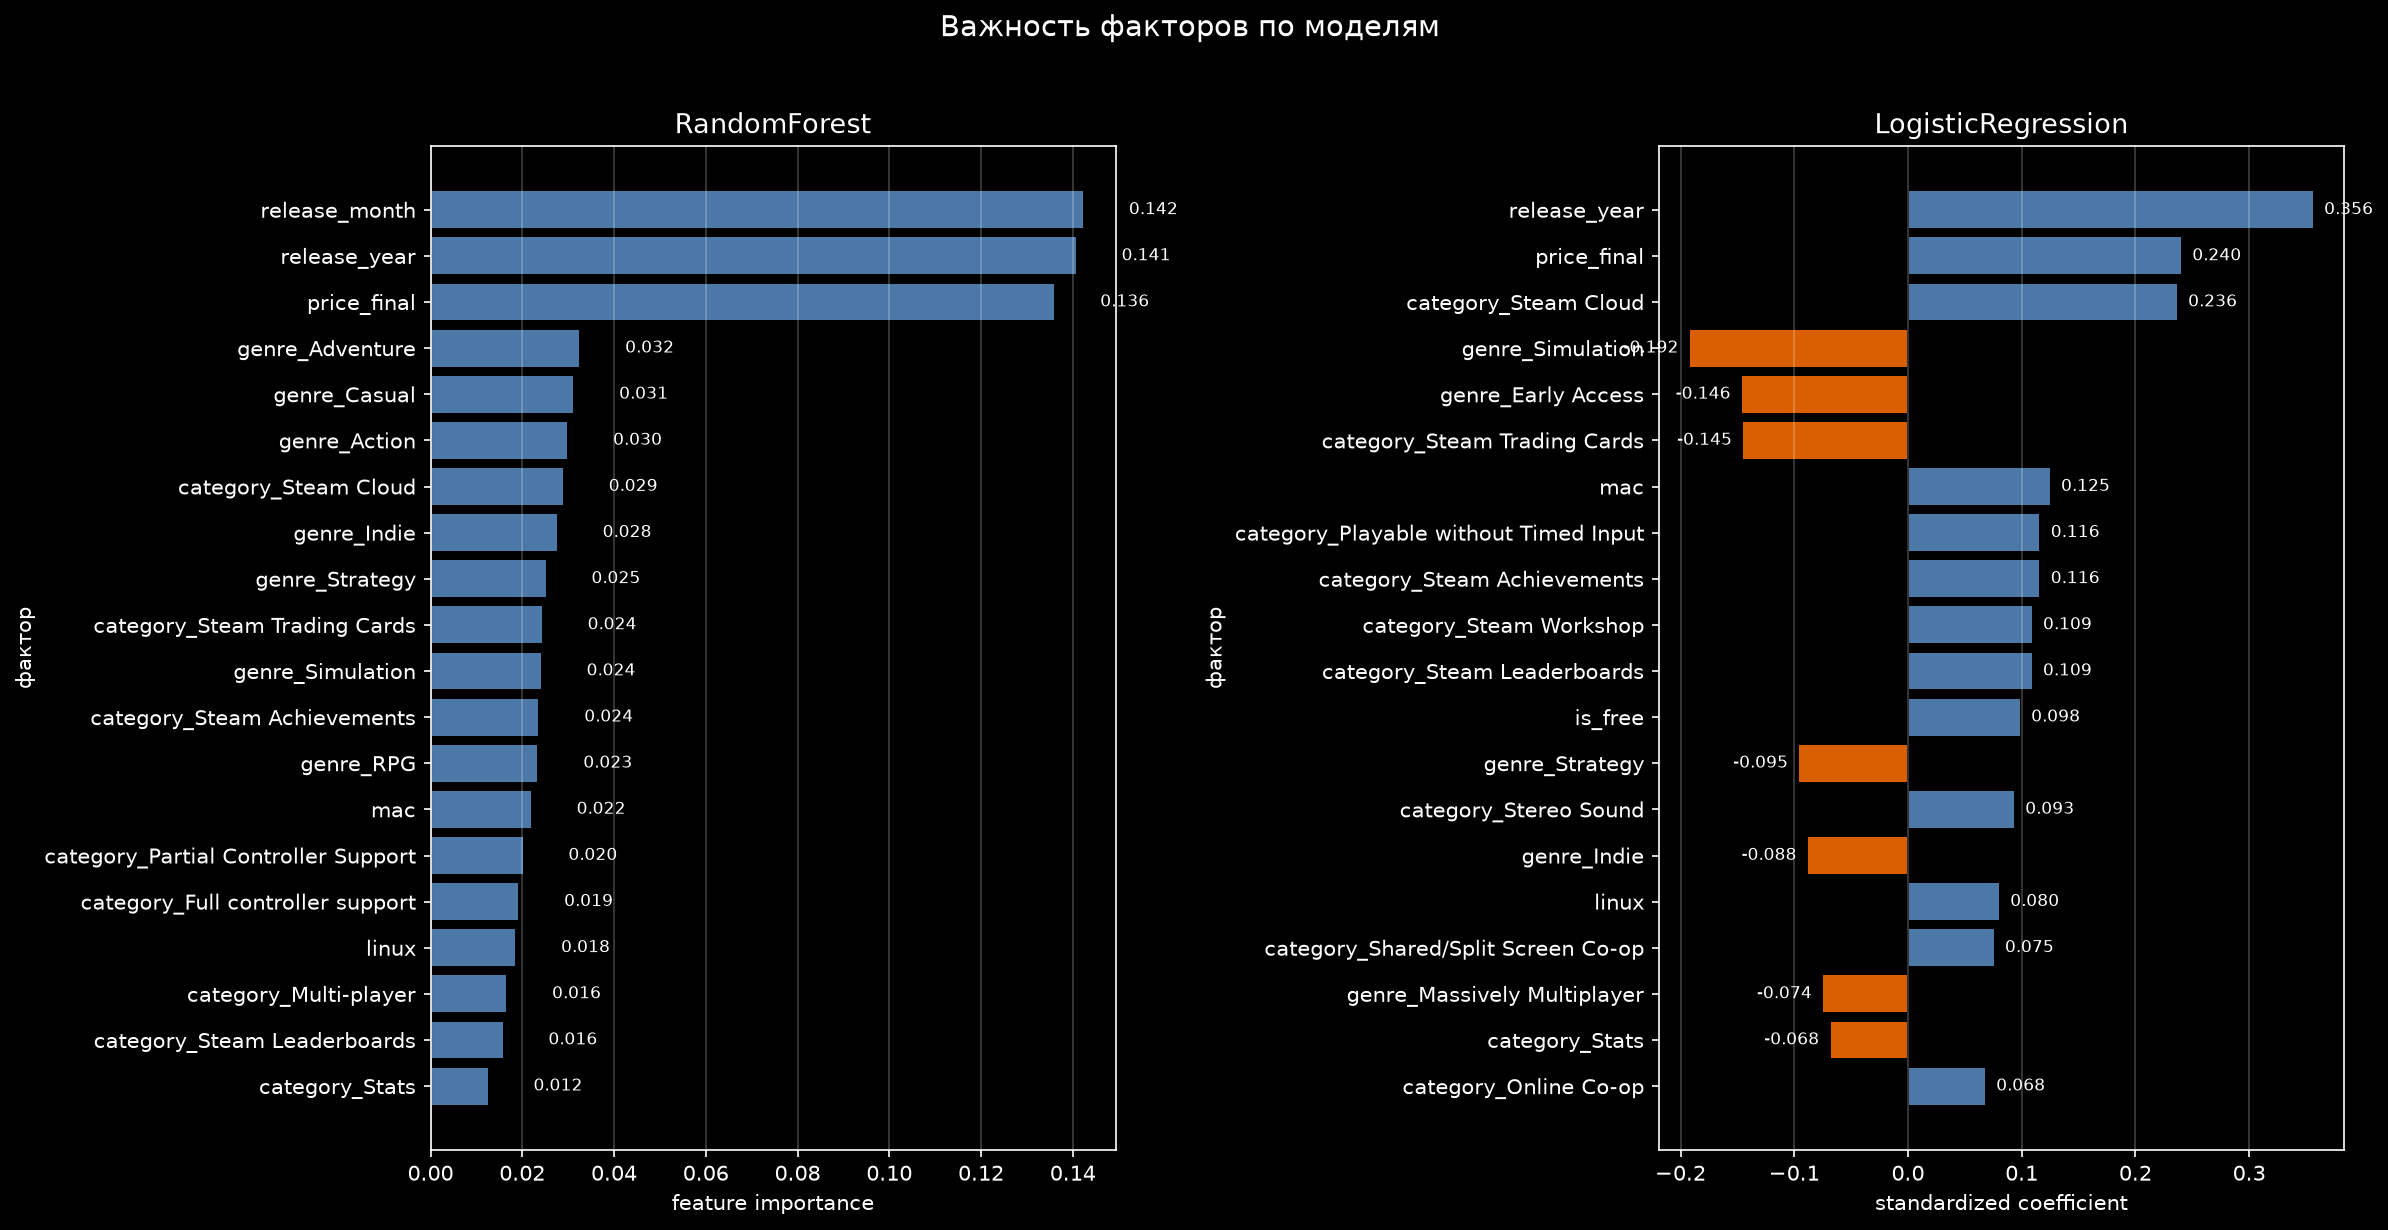

In [22]:
def get_model_feature_scores(
    results: dict[str, dict[str, object]],
    feature_names: list[str],
) -> dict[str, pd.DataFrame]:
    # важности random forest и коэффициенты logistic regression
    scores = {}

    for model_name, result in results.items():
        model = result["model"]

        if model_name == "RandomForest":
            values = model.feature_importances_
            scores[model_name] = pd.DataFrame(
                {
                    "feature": feature_names,
                    "score": values,
                    "abs_score": np.abs(values),
                    "direction": "importance",
                }
            ).sort_values("abs_score", ascending=False)
            continue

        if model_name == "LogisticRegression":
            estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model
            positive_index = list(estimator.classes_).index("positive")
            if estimator.coef_.shape[0] == 1:
                values = estimator.coef_[0]
            else:
                values = estimator.coef_[positive_index]
            scores[model_name] = pd.DataFrame(
                {
                    "feature": feature_names,
                    "score": values,
                    "abs_score": np.abs(values),
                    "direction": np.where(values >= 0, "positive", "not_positive"),
                }
            ).sort_values("abs_score", ascending=False)

    return scores


def plot_model_feature_scores(
    feature_scores: dict[str, pd.DataFrame],
    path: Path,
    top_n: int = 20,
) -> None:
    # сравнение того, какие признаки важны для разных моделей
    fig, axes = plt.subplots(
        1,
        len(feature_scores),
        figsize=(8 * len(feature_scores), 8),
        squeeze=False,
    )

    for ax, (model_name, scores_df) in zip(axes[0], feature_scores.items()):
        plot_df = scores_df.head(top_n).iloc[::-1].copy()

        if model_name == "RandomForest":
            colors = ["#4C78A8"] * len(plot_df)
            xlabel = "feature importance"
        else:
            colors = [
                "#4C78A8" if value >= 0 else "#D95F02"
                for value in plot_df["score"]
            ]
            xlabel = "standardized coefficient"

        bars = ax.barh(plot_df["feature"], plot_df["score"], color=colors)
        ax.axvline(0, color="#333333", linewidth=1)
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("фактор")
        ax.grid(axis="x", alpha=0.25)

        for bar, value in zip(bars, plot_df["score"]):
            offset = 0.01 if value >= 0 else -0.01
            ha = "left" if value >= 0 else "right"
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va="center",
                ha=ha,
                fontsize=8,
            )

    fig.suptitle("Важность факторов по моделям", fontsize=14, y=1.02)
    fig.tight_layout()

    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

feature_scores = get_model_feature_scores(
    results=results,
    feature_names=list(X.columns),
)

plot_model_feature_scores(feature_scores, MODEL_IMPORTANCE_PLOT_PATH)
display(Image(filename=str(MODEL_IMPORTANCE_PLOT_PATH)))

У RandomForest самыми заметными факторами стали `release_month`, `release_year` и `price_final`, но importance не показывает направление влияния. У LogisticRegression знак коэффициента интерпретируется напрямую: например, положительный коэффициент `release_year` двигает прогноз к `positive`, а отрицательные коэффициенты вроде `genre_Simulation` или `genre_Early Access` - к `not_positive`. Это не доказывает причинность, а показывает связь в текущем датасете.